> **Actualización 2026:** Se introduce *Programación Dinámica* (DP) 
> como puente entre optimización secuencial y Reinforcement Learning.


# Modelado en Optimización (IIND-2501)

## Lección 3.8: Programación Dinámica


> **Conexión con las lecciones anteriores:** En las lecciones 3.1-3.7 hemos visto cómo resolver problemas de optimización 
> con distintas estrategias: búsqueda local, descenso de gradiente, Simplex, Branch & Bound, y heurísticas. 
> Todos estos métodos asumen que las decisiones se toman **simultáneamente**. 
> Ahora abordaremos problemas donde las decisiones son **secuenciales** — cada decisión depende del *estado* actual y afecta los estados futuros.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from helpers_dp import (
    crear_red_etapas, dp_backward, reconstruir_camino,
    visualizar_red, dp_to_lp
)


## 1 — Introducción a la Programación Dinámica

La **Programación Dinámica** (DP) es una técnica para resolver problemas de optimización que pueden descomponerse en **etapas** o **períodos**. 
Su fundamento es el **Principio de Optimalidad de Bellman** (1957):

> *Una política óptima tiene la propiedad de que, independientemente de las decisiones iniciales, 
> las decisiones restantes deben constituir una política óptima con respecto al estado resultante de la primera decisión.*

Formalmente, si $V_t(s)$ es el costo mínimo para ir desde el estado $s$ en la etapa $t$ hasta el destino final:

$$
V_t(s) = \min_{a \in A(s)} \bigl\{c(s,a) + V_{t+1}\bigl(f(s,a)\bigr)\bigr\}
$$

donde:
- $A(s)$: conjunto de acciones posibles en el estado $s$
- $c(s,a)$: costo inmediato de tomar la acción $a$ en el estado $s$
- $f(s,a)$: estado siguiente tras tomar la acción $a$

La ecuación se resuelve **de atrás hacia adelante** (*backward induction* o *inducción hacia atrás*).


---
### Pregunta de Reflexión

1. ¿En qué se diferencia la programación dinámica de la *búsqueda local* (Lección 3.1)?
2. ¿Por qué es importante que el problema tenga **estructura de etapas**?


## 2 — Ejemplo: Camino más corto en una red por etapas (*Stagecoach Problem*)

Consideremos el clásico problema del diligente: un viajero debe ir de la ciudad **A** a la ciudad **E**, 
pasando por varias ciudades intermedias organizadas en etapas. En cada etapa, elige a qué ciudad ir, 
pagando un costo (distancia, peaje, etc.) por cada arco.

**Objetivo:** encontrar el camino de costo mínimo de A a E.


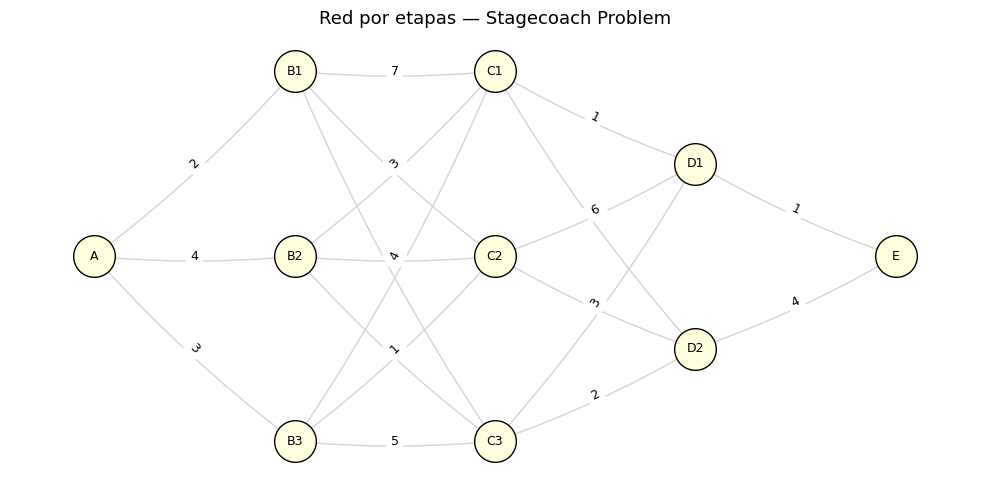

In [2]:
# Crear la red de etapas
grafo, etapas, pos = crear_red_etapas()

# Visualizar la red (sin política aún)
visualizar_red(grafo, pos, titulo='Red por etapas — Stagecoach Problem')


### Resolución por Inducción Hacia Atrás

Partimos del destino E ($V(E)=0$) y vamos calculando $V_t(s)$ para cada nodo, 
moviéndonos hacia atrás por las etapas:


In [3]:
# Resolver con DP (backward induction)
V, pi = dp_backward(grafo, etapas)

# Mostrar función de valor y política
print('Función de Valor V(s):')
for s in sorted(V.keys()):
    print(f'  V({s}) = {V[s]}')

print('\nPolitica optima pi(s):')
for s in sorted(pi.keys()):
    print(f'  pi({s}) = {pi[s]}')

# Reconstruir y mostrar camino óptimo
camino_opt = reconstruir_camino(pi)
print(f'\nCamino optimo: {" -> ".join(camino_opt)}')
print(f'Costo optimo:  {V["A"]}')


Función de Valor V(s):
  V(A) = 9
  V(B1) = 9
  V(B2) = 5
  V(B3) = 6
  V(C1) = 2
  V(C2) = 7
  V(C3) = 4
  V(D1) = 1
  V(D2) = 4
  V(E) = 0

Politica optima pi(s):
  pi(A) = B2
  pi(B1) = C1
  pi(B2) = C1
  pi(B3) = C1
  pi(C1) = D1
  pi(C2) = D1
  pi(C3) = D1
  pi(D1) = E
  pi(D2) = E

Camino optimo: A -> B2 -> C1 -> D1 -> E
Costo optimo:  9


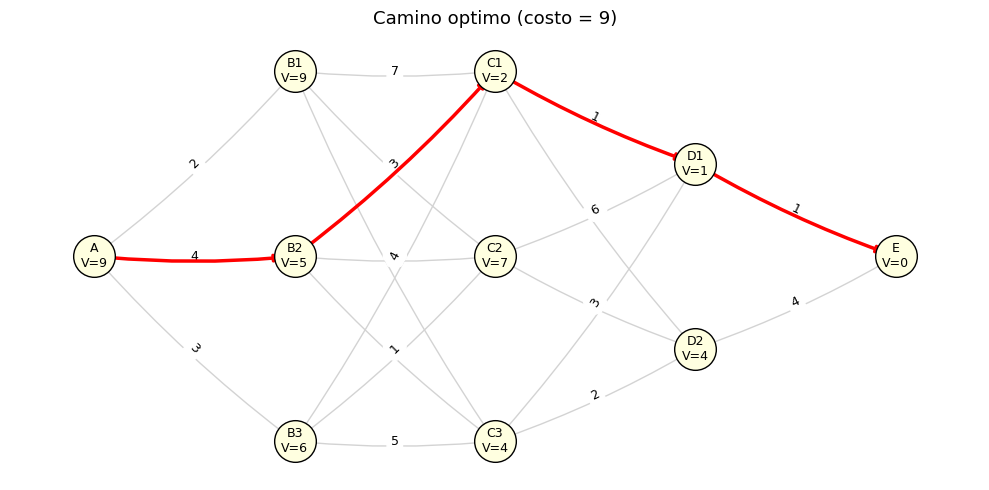

In [4]:
# Visualizar la red con la política óptima resaltada
visualizar_red(grafo, pos, politica=pi, V=V,
               titulo=f'Camino optimo (costo = {V["A"]})')


---
### Pregunta de Reflexión

1. ¿Cuál es la relación entre la función de valor $V_t(s)$ y el concepto de *incumbente* que vimos en búsqueda local?
2. ¿Qué ventaja tiene resolver el problema *de atrás hacia adelante* en lugar de enumerar todos los caminos?
3. Si hubiera $k$ nodos por etapa y $T$ etapas, ¿cuántas operaciones requiere DP vs. enumeración exhaustiva?


## 3 — DP → LP: "Achatando" un problema secuencial

Cualquier problema de camino más corto en un grafo dirigido se puede formular como un **programa lineal** 
de flujo de costo mínimo:

$$
\min \sum_{(i,j) \in \mathcal{A}} c_{ij} \, x_{ij}
$$
$$
\text{s.a.} \quad \sum_{j:(i,j)\in\mathcal{A}} x_{ij} - \sum_{j:(j,i)\in\mathcal{A}} x_{ji} = 
\begin{cases} 1 & \text{si } i = \text{origen} \\ -1 & \text{si } i = \text{destino} \\ 0 & \text{en otro caso} \end{cases}
$$
$$x_{ij} \geq 0 \quad \forall (i,j)$$

Esto "achata" la estructura de etapas en una formulación **masiva** pero lineal. 
Verifiquemos que ambas formulaciones dan el **mismo resultado**:


In [5]:
# Resolver el mismo problema como LP con PuLP
z_lp, flujos = dp_to_lp(grafo)

print(f'Costo optimo (LP):  {z_lp}')
print(f'Costo optimo (DP):  {V["A"]}')
print(f'Equivalencia:       {abs(z_lp - V["A"]) < 1e-6}')

print('\nFlujos optimos (arcos activos):')
for (s, s2), val in sorted(flujos.items()):
    print(f'  {s} -> {s2}: x = {val:.1f}')


Costo optimo (LP):  9.0
Costo optimo (DP):  9
Equivalencia:       True

Flujos optimos (arcos activos):
  A -> B2: x = 1.0
  B2 -> C1: x = 1.0
  C1 -> D1: x = 1.0
  D1 -> E: x = 1.0


---
### Pregunta de Reflexión

1. ¿Cuáles son las **ventajas computacionales** de DP sobre la formulación LP para problemas con estructura de etapas?
2. ¿En qué situaciones podría ser preferible usar el LP? (*Pista: piense en la flexibilidad para agregar restricciones adicionales.*)
3. Note que las variables $x_{ij}$ del LP son **continuas**, pero la solución óptima es **entera** ($0$ o $1$). 
   ¿Por qué ocurre esto? (*Pista: propiedad de total unimodularidad.*)


## 4 — Puente hacia Reinforcement Learning

La **ecuación de Bellman** que usamos para resolver el *stagecoach problem* es, de hecho, 
el fundamento teórico del **Reinforcement Learning** (RL).

La relación clave es:

| Concepto DP | Concepto RL |
|:--:|:--:|
| Estado $s$ | Estado del agente |
| Acción $a$ | Acción del agente |
| Costo $c(s,a)$ | Recompensa $r(s,a)$ (negativa) |
| Función de valor $V(s)$ | Value function |
| Política $\pi(s)$ | Policy |
| Inducción hacia atrás | Value Iteration |

**DP asume que conocemos el modelo** — es decir, sabemos exactamente los costos $c(s,a)$ y las transiciones $f(s,a)$. 
En RL, el agente **no conoce el modelo** y debe aprenderlo interactuando con el entorno.

```
   DP (modelo conocido)        RL (modelo desconocido)
   ────────────────────        ──────────────────────
   Value Iteration        →   Q-Learning / SARSA
   Policy Iteration       →   Policy Gradient
   Bellman Optimality Eq. →   Q-function update
```

Este puente entre DP y RL muestra cómo los principios de **optimización secuencial** 
se extienden naturalmente al mundo del aprendizaje por refuerzo — un tema avanzado 
que podrán explorar en cursos posteriores.


---
### Pregunta de Reflexión

1. ¿Qué ocurre cuando **no conocemos** el modelo de transición $f(s,a)$? ¿Cómo podría un agente aprender la política óptima sin este conocimiento?
2. ¿Ve alguna conexión entre el concepto de *incumbente* (Lección 3.1) y la *función de valor* $V(s)$?
3. ¿Cómo se relaciona el *learning rate* del descenso de gradiente (Lección 3.2) con el *factor de descuento* $\gamma$ en RL?


---
> **Política de uso de IA (artículos 80-82 del syllabus):** 
> Si utiliza herramientas de IA generativa (ChatGPT, Copilot, Gemini, etc.) para apoyar sus entregas, 
> debe citar la herramienta utilizada y el *prompt* empleado. 
> El incumplimiento de esta política será tratado como falta académica.
